In [ ]:
import pandas as pd
from rdkit import Chem

df = pd.read_csv('scaled_output.csv')
df_original = df_original = pd.read_csv('../polygraphpy/data/original_dataset.csv')
df_original = df_original[['smiles', 'mw']]

df = df.merge(df_original, on='smiles')

atoms_number = []

for i in df['smiles'].values:
    mol = Chem.MolFromSmiles(i)
    mol_with_hs = Chem.AddHs(mol)
    num_all_atoms = mol_with_hs.GetNumAtoms()

    atoms_number.append(num_all_atoms)

df['number_of_atoms'] = atoms_number

#df_aux = df[df['mw'] <= 300]
df = df[0.33333 <= df['static_polarizability']*1.20].reset_index(drop=True)
df = df[0.33333 >= df['static_polarizability']*0.80].reset_index(drop=True)
df_aux = df[df['number_of_atoms'] <= 40]
len(df_aux)

KeyError: 'target_scaled'

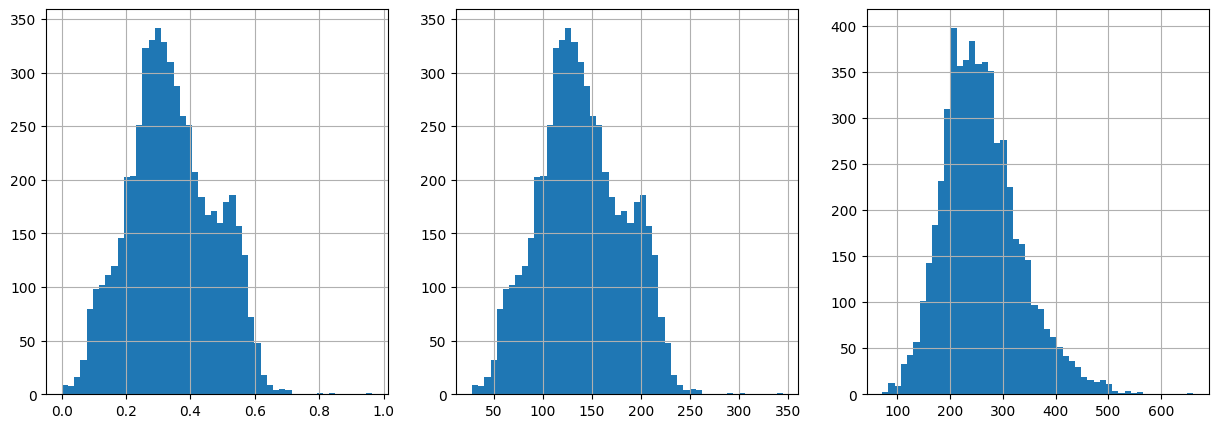

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
df_aux['static_polarizability'].hist(bins=50)

plt.subplot(1,3,2)
df_aux['static_polarizability_original'].hist(bins=50)

plt.subplot(1,3,3)
df_aux['mw'].hist(bins=50)

plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler

df_copoly = pd.read_csv('../polygraphpy/data/polarizability_data_copoly.csv')

#outlier treatment
Q1 = df_copoly['static_polarizability'].quantile(0.25)
Q3 = df_copoly['static_polarizability'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_copoly = df_copoly[(df_copoly['static_polarizability'] >= lower_bound) & (df_copoly['static_polarizability'] <= upper_bound)].reset_index(drop=True)

#minmaxscaler
scaler = MinMaxScaler()

df_copoly['static_polarizability' + '_original'] = df_copoly['static_polarizability']
scaler = scaler.fit(df_copoly[['static_polarizability']])
df_copoly['static_polarizability'] = scaler.transform(df_copoly[['static_polarizability']])


<Axes: >

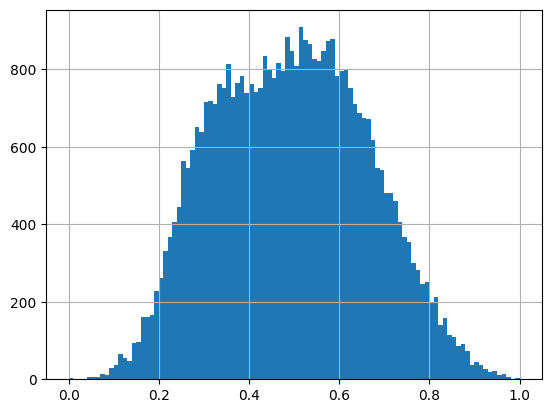

In [2]:
df_copoly['static_polarizability'].hist(bins=100)

In [3]:
df_grouped = df_copoly.groupby('smiles_A').count().sort_values(by='id_A').reset_index()
df_grouped = df_grouped[df_grouped['id_A'] >= 120]
df_merged = df_copoly[df_copoly['smiles_A'].isin(df_grouped['smiles_A'])]

In [4]:
Q1 = df_merged['static_polarizability'].quantile(0.25)
Q3 = df_merged['static_polarizability'].quantile(0.75)

df_merged = df_merged[(df_merged['static_polarizability'] >= Q1) & (df_merged['static_polarizability'] <= Q3)]

In [5]:
(df_merged.shape, df_merged['smiles_A'].nunique(), df_merged['smiles_B'].nunique())

((9999, 11), 122, 479)

<Axes: >

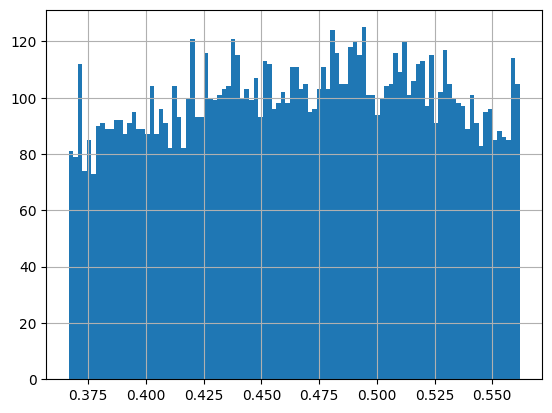

In [6]:
df_merged['static_polarizability'].hist(bins=100)